## Stroke Prediction Notebook

In [32]:
# Step 1: Install required packages (run if needed)

# Step 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [3]:
# Step 3: Load dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")  # Replace with your dataset path

# Step 4: Basic EDA
print("Dataset shape:", data.shape)
print(data.head())
print("\nMissing values per column:\n", data.isnull().sum())
print("\nStroke distribution:\n", data['stroke'].value_counts())


Dataset shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

Missing values per column:
 i

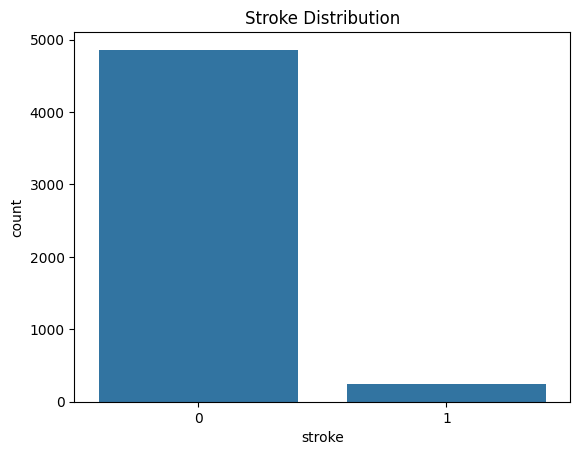

In [4]:
# Step 4a: Visualize target
sns.countplot(x='stroke', data=data)
plt.title("Stroke Distribution")
plt.show()


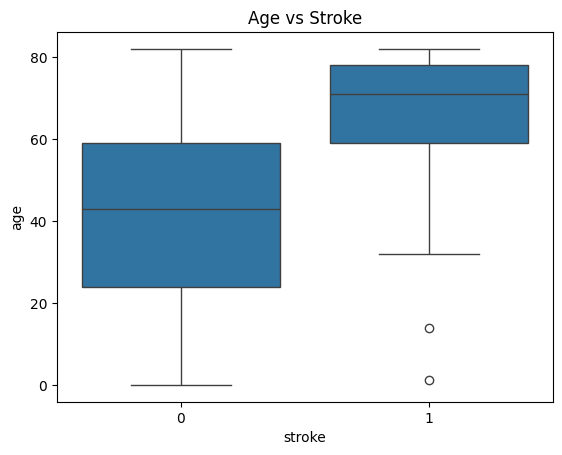

In [5]:
# Step 4b: Age vs Stroke
sns.boxplot(x='stroke', y='age', data=data)
plt.title("Age vs Stroke")
plt.show()

In [7]:
# Step 5: Handle missing values using imputer
num_cols = ['bmi', 'age', 'avg_glucose_level']
imputer = SimpleImputer(strategy='median')
data[num_cols] = imputer.fit_transform(data[num_cols])

# Step 6: Encode categorical variables
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [8]:
# Step 7: Split data
X = data.drop('stroke', axis=1)
y = data['stroke']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", sum(y_train==1))
print("After SMOTE:", sum(y_train_res==1))

Before SMOTE: 199
After SMOTE: 3889


c:\Users\Ismat\anaconda3\envs\st_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [27]:
# Step 8: Define classifiers and parameter grids
models = {
    "RandomForest": RandomForestClassifier(class_weight='balanced',random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

params = {
    "RandomForest": {"n_estimators": [100, 200], "max_depth": [None, 5, 10]},
    "GradientBoosting": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3,5]},
    "LogisticRegression": {"C": [0.1, 1, 10], "solver": ["lbfgs"]},
    "XGBoost": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3,5]}
}

# Step 9: Train with GridSearchCV and find best model
best_score = 0
best_model = None
best_name = ""

for name in models:
    print(f"\nTraining {name}...")
    clf = GridSearchCV(models[name], params[name], cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_res, y_train_res)
    score = clf.best_score_
    print(f"Best CV accuracy for {name}: {score:.4f}")
    if score > best_score:
        best_score = score
        best_model = clf.best_estimator_
        best_name = name

print(f"\nBest Model: {best_name} with CV accuracy {best_score:.4f}")



Training RandomForest...
Best CV accuracy for RandomForest: 0.9690

Training GradientBoosting...
Best CV accuracy for GradientBoosting: 0.9604

Training LogisticRegression...
Best CV accuracy for LogisticRegression: 0.7884

Training XGBoost...


c:\Users\Ismat\anaconda3\envs\st_env\lib\site-packages\xgboost\core.py:158: UserWarning: [22:41:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best CV accuracy for XGBoost: 0.9550

Best Model: RandomForest with CV accuracy 0.9690


In [28]:
# Step 10: Evaluate on test set
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9295499021526419
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.18      0.12      0.14        50

    accuracy                           0.93      1022
   macro avg       0.57      0.55      0.55      1022
weighted avg       0.92      0.93      0.92      1022



[[944  28]
 [ 44   6]]


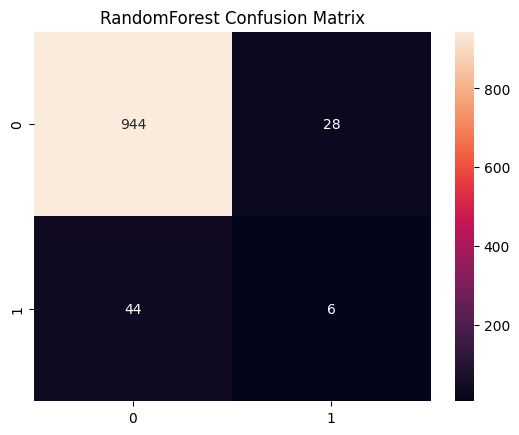

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"{best_name} Confusion Matrix")
plt.show()


In [30]:
# Step 11: Save best model and scaler
with open("best_stroke_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"{best_name} saved successfully!")

RandomForest saved successfully!
